In [219]:
from jax.lax import integer_pow_p
import jax 

import numpy as np

import jax.numpy as jnp
import jax.random as jrandom
from jax import lax

from jax.scipy.optimize import minimize

from probjax.distributions import MultivariateNormal
from probjax.core.jaxpr_propagation.graph import JaxprGraph

import matplotlib.pyplot as plt

from sbi.analysis import pairplot

import haiku as hk

In [257]:
hidden_dim = 50
input_dim = 2
output_dim = 50
W1 = jrandom.normal(jrandom.PRNGKey(1), (hidden_dim,input_dim)) 
W2 = jrandom.normal(jrandom.PRNGKey(2), (output_dim, hidden_dim)) 
b1 = jrandom.normal(jrandom.PRNGKey(42), (hidden_dim,))

# SVDs give you all info
U1, S1, V_T1 = jnp.linalg.svd(W1)
U2, S2, V_T2= jnp.linalg.svd(W2)
effective_dim1 = jnp.sum(S1 > 1e-5)
effective_dim2 = jnp.sum(S2 > 1e-5)
free_dim1 = W1.shape[1] - effective_dim1
free_dim2 = W2.shape[1] - effective_dim2

parameter_dim = int(free_dim1 + free_dim2)
print(effective_dim1, effective_dim2)
print(free_dim1, free_dim2)
print(parameter_dim)

# Projection matrix
P1 = W1 @ jnp.linalg.inv(W1.T @ W1) @ W1.T
P2 = W2 @ jnp.linalg.inv(W2.T @ W2) @ W2.T

2 50
0 0
0


In [266]:
@jax.jit
def f(key, x):
    eps = jrandom.normal(key, (output_dim,))* 0.01
    y1 = W1 @ x
    y2 = y1 + b1
    y3 = jax.nn.leaky_relu(y2, negative_slope=0.01)
    y4 = W2 @ y3
    y5 = y4 + eps
    return y5, (y1, y2, y3,)

@jax.jit
def f_inv(y5, theta):
    theta1 = theta[:-output_dim]
    theta2 = theta[-output_dim:]

    y4 = y5 - theta2* 0.01
    _y4 = P2 @ y4
    error = jnp.mean(jnp.sum(jnp.abs(_y4 - y4), -1))
    y4 = jnp.where(error <= 1e-4, y4, _y4)
    # By assumption y4 is output of f(x) and thus in the image space of W2
    y3 = jnp.linalg.pinv(W2) @ y4 + V_T2.T[:,effective_dim2:] @ jnp.atleast_1d(theta1) # 49 dim vector of free parameters
    # _y3 = jnp.clip(y3,-1 + 1e-7, 1 - 1e-7)
    # error = jnp.mean(jnp.abs(_y3- y3))
    # y3 = jax.lax.cond(error == 0., lambda : y3, lambda : _y3)
    y2 = jax.nn.leaky_relu(y3, negative_slope=100.)
    y1 = y2 - b1
    _y1 = P1 @ y1 # Must be in image space of W1
    e = jnp.mean(jnp.abs((_y1 - y1)).sum(-1))
    y1 = jnp.where(e <= 1e-4, y1, _y1)
    error = error + e
    x = jnp.linalg.pinv(W1) @ y1  # Here we need also free parameters ... if we reduce or increase dimensionality
    return x, error, (y1, y2, y3,)

In [267]:
xs = jax.random.normal(jrandom.PRNGKey(42), (1000,input_dim))
keys = jrandom.split(jrandom.PRNGKey(43), 1000)
ys, trace = jax.vmap(f)(keys,xs)
#
_ = f_inv(ys[0], jnp.zeros((parameter_dim + output_dim,)))

In [268]:
d = parameter_dim + output_dim

def net(eps, ys):
    mlp = hk.nets.MLP([200, 200,200,200,200,200, d])
    inp = jnp.concatenate([eps, ys], axis=-1)
    return mlp(inp)


init, g = hk.without_apply_rng(hk.transform(net))
params = init(jrandom.PRNGKey(0), jnp.ones((1,d)), jnp.ones((1,output_dim)))
jax.jit(g)(params, jnp.ones((1,d)), jnp.ones((1,output_dim))).shape

(1, 50)

In [269]:
def sliced_wasserstein2_distance(key, xs, ys, num_projections=100):
    """
    Computes the Sliced Wasserstein-2 distance between two sets of samples.

    Args:
        key: jax.random.PRNGKey
        xs: jnp.ndarray, shape (n, d)
        ys: jnp.ndarray, shape (m, d)
        num_projections: int, number of projections to use
    
    Returns:
        swd: float, sliced wasserstein distance
    """

    # Generate random projections
    projections = jax.random.normal(key, shape=(num_projections, xs.shape[1]))

    # Compute projections
    xs_projections = jnp.dot(xs, projections.T)
    ys_projections = jnp.dot(ys, projections.T)

    # Sort projections
    xs_projections = jnp.sort(xs_projections, axis=0)
    ys_projections = jnp.sort(ys_projections, axis=0)

    # Compute sliced wasserstein distance
    swd = jnp.sqrt(jnp.sum((xs_projections - ys_projections) ** 2)) / num_projections

    return swd

In [275]:
import optax
optimizer = optax.adam(1e-3)
opt_state = optimizer.init(params)


def loss_fn_error(params, key):
    key1, key2 = jrandom.split(key)
    eps = jrandom.normal(key1, (ys.shape[0],d))
    thetas = g(params, eps, ys)
    x_hat, error, trace_rec = jax.vmap(f_inv, in_axes=(0, 0))(ys, thetas)
    y3 = trace_rec[-1]
    y3_true = trace[-1]

    return  jnp.mean(error) +sliced_wasserstein2_distance(key2, x_hat, xs, num_projections=100)


@jax.jit
def update(params, opt_state, key):
    grads = jax.grad(loss_fn_error)(params, key)
    updates, opt_state = optimizer.update(grads, opt_state)
    new_params = optax.apply_updates(params, updates)
    return new_params, opt_state

In [276]:
key = jrandom.PRNGKey(1)
for i in range(5000):
    key, subkey = jrandom.split(key)
    params, opt_state = update(params, opt_state, subkey)
    if i % 500 == 0:
        print(loss_fn_error(params, subkey))

991.958
84.983826
58.634148
57.875248


KeyboardInterrupt: 

In [280]:
import numpy as np
xs = jax.random.normal(jrandom.PRNGKey(69), (1000,input_dim)) 
keys = jrandom.split(jrandom.PRNGKey(42), 1000)
ys, trace = jax.vmap(f)(keys,xs)

thetas =  g(params, jrandom.normal(jrandom.PRNGKey(42), (ys.shape[0],d)), ys)
xs_rec, error, trace_rec = jax.vmap(f_inv)(ys,thetas)
ys_rec = jax.vmap(f)(keys,xs_rec)[0]

print(jnp.mean(jnp.abs(xs_rec - xs)))
print(jnp.mean(jnp.abs(ys_rec - ys)))
print(jnp.mean(jnp.abs(error)))

0.4095816
2.3683233
53.865944


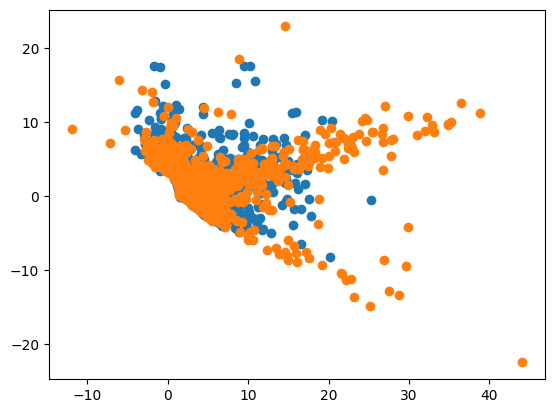

In [273]:
plt.scatter(ys[:,0], ys[:,1], label='y')
plt.scatter(ys_rec[:,0], ys_rec[:,1], label='y_rec')

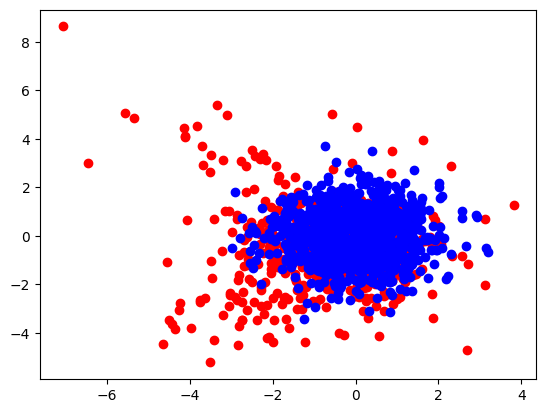

In [274]:
plt.scatter(xs_rec[:,0], xs_rec[:,1], c="r", label="reconstructed")
plt.scatter(xs[:,0], xs[:,1], c="b", label="original")

In [239]:
x = jax.random.normal(jrandom.PRNGKey(42), (input_dim,))
y = f(key,x)[0]
eps = jrandom.normal(jrandom.PRNGKey(42), (1000,d))
thetas = g(params, eps, jnp.ones((1000,1))*y)
x_rec, error, _ = jax.vmap(f_inv, in_axes=(None, 0))(y, thetas)
y_rec = jax.vmap(f)(keys,x_rec)[0]
print(jnp.mean(error))

2.1747072


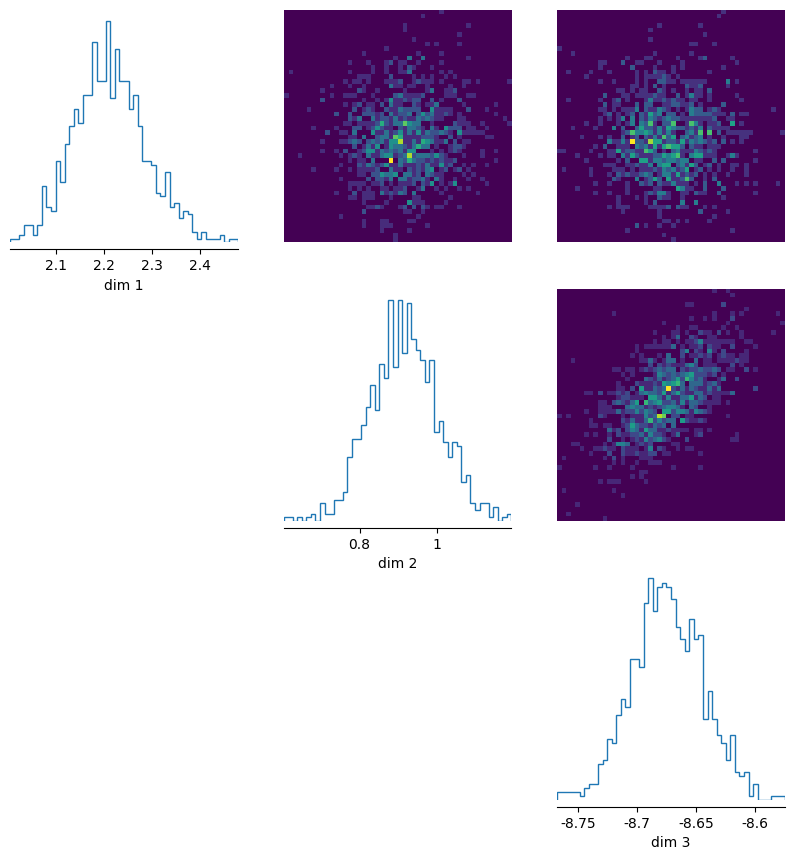

In [240]:
_ = pairplot(np.array(thetas[...,-3:]))

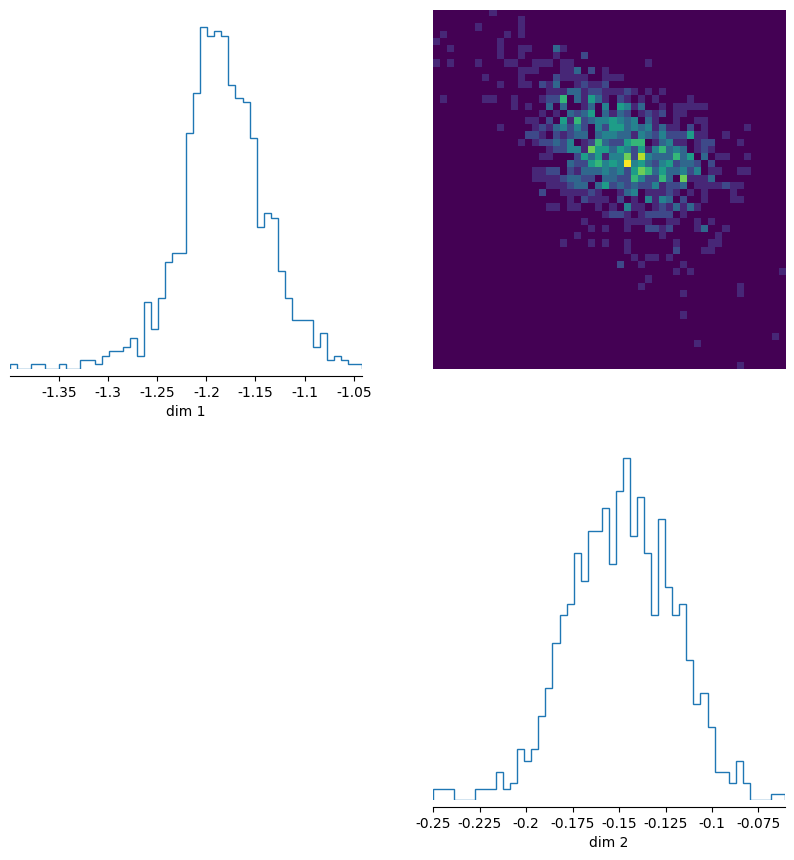

In [181]:
_ = pairplot(np.array(x_rec))

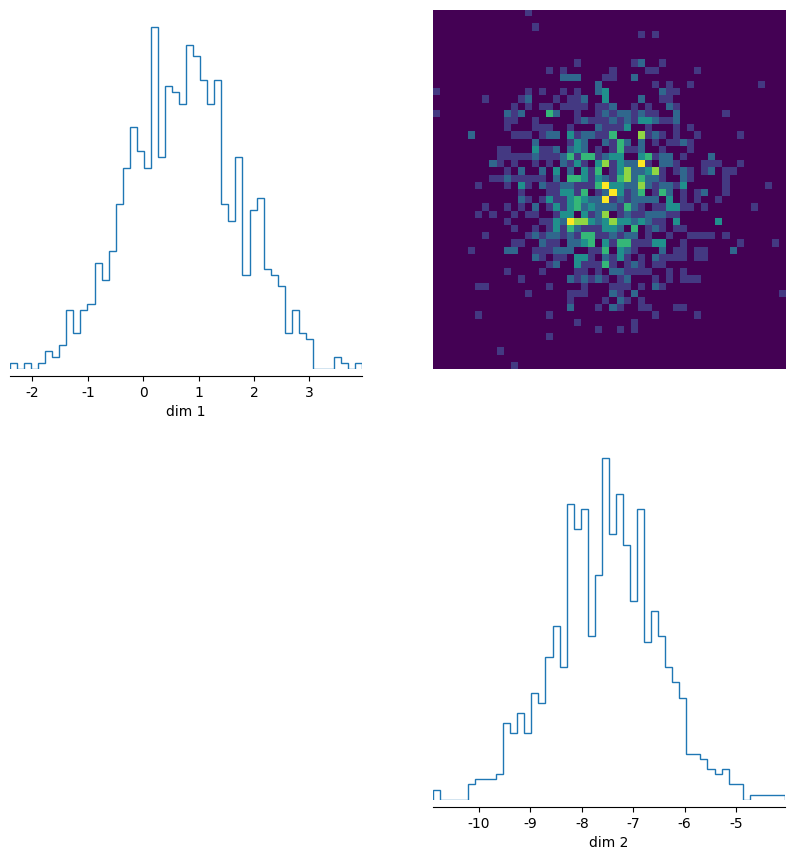

In [182]:
_ = pairplot(np.array(y_rec[...,:5]))

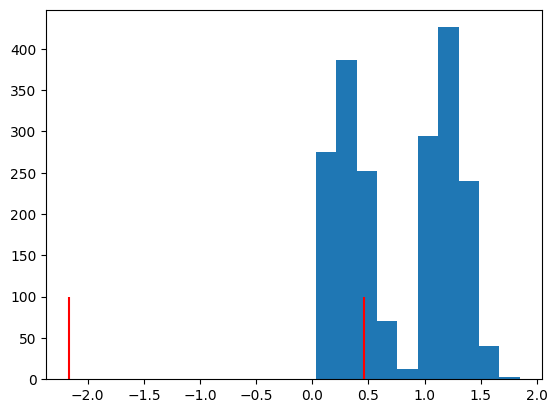

In [241]:
_ = plt.hist(x_rec.reshape(-1))
plt.vlines(x, 0, 100, color="red")

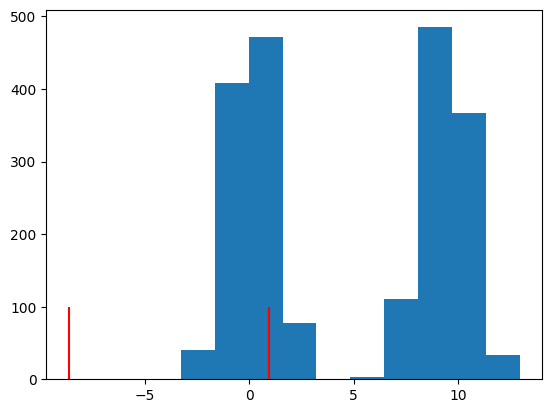

In [242]:
_ = plt.hist(y_rec.reshape(-1))
plt.vlines(y, 0, 100, color="red")